<a href="https://colab.research.google.com/github/reblekah/UASLidarWorkshop_SKC_2026/blob/main/UAS_Lidar_Workshop_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Headwaters Tech Hub Lidar Workshop
##September 25th, 2026
Welcome to the UAS Symposium and the lidar data use and management session!
All the code, data, and information shown in this workshop are open access and clearly documented for you to use.
This workshop is being taught in R (https://www.r-project.org/) which is a free an open source programming language built for statistics but with evolving uses and applications. Before we get started, go to the Runtime option on the ribbon above, and click "Change Runtime Type" followed by changing the runtime to "R" and the version to "2026.07"

We’re going to practice some initial data management using R. This includes the following:
Access an LAZ point cloud file

1.   Access an LAZ point cloud file
2.   Filtering data for specific use-cases
3.   Plotting and visualizing data
4.   Running simple ground-detection algorithms and DTM/DSM generation
5.   Tree top detection and set up for more advanced machine learning or analysis use cases (with enough time)


Filtering data for specific use-cases
Plotting and visualizing data
Running simple ground-detection algorithms and DEM/DTM generation
(if we have time) Tree top detection and set up for more advanced machine learning or analysis use-cases.


If you have any questions, feel free to contact me and see the sources below for more information.

Rebekah Fields: rebekah_fields@skc.edu

Sources:

USGS Lidar Data: https://apps.nationalmap.gov/lidar-explorer/#/

There are 4 essential packages we will use for this workshop.
For your reference, here are the links to the documentation:
lidR: https://cran.r-project.org/web/packages/lidR/lidR.pdf , https://r-lidar.github.io/lidRbook/

terra: https://rspatial.org/ , https://cran.r-project.org/web/packages/terra/terra.pdf

raster: https://cran.r-project.org/web/packages/raster/raster.pdf

sp/sf: https://cran.r-project.org/web/packages/sf/sf.pdf


#Package Access and Download

In [ ]:
#This script was developed using R Version 4.6.0 - any later versions should update packages for full compatibility
#R.version.string

This is some backend setup for functionality. It is required to run this code and make sure the packages we use are compatible. This whole section should take less than 2 minutes.

In [ ]:
system("apt-get update -qq")
system2(
  "dpkg",
  c("--configure", "-a"),
  stdout = TRUE,
  stderr = TRUE
)
system2(
  "apt-get",
  c("-f", "install", "-y"),
  stdout = TRUE,
  stderr = TRUE
)
system2(
  "apt-get",
  c("install", "-y", "r-cran-raster","r-cran-terra", "r-cran-sf", "r-cran-sp","r-cran-lidr", "r-cran-rcsf"),
  stdout = TRUE,
  stderr = TRUE
)

In [ ]:
library(sf)
library(raster)
library(ggplot2)
library(dplyr)
library(sp)
library(lidR)

#Lidar Data Access
Now we're going to access our lidar data. I already downloaded the compressed point cloud file, known as an .LAZ file. The link above is from the USGS Lidar Explorer, but any LAZ file will work here!
This section allows you to access the file through Google Drive, saving the file as "lidar_site.laz" in the local storage within Colab.
I will highlight below where you would just point to a local file stored on your machine to import the dataset that way.

In [ ]:
install.packages("googledrive")
library(googledrive)
drive_deauth()
file_id <- "1wfWEwo-ECBe5QWec42sl-jXXBE0IROm5" #Actual link to shared file: https://drive.google.com/file/d/1wfWEwo-ECBe5QWec42sl-jXXBE0IROm5/view?usp=sharing
public_file <- drive_get(as_id(file_id))
drive_download(public_file, path = "lidar_site.laz", overwrite = TRUE)

##Area of Interest

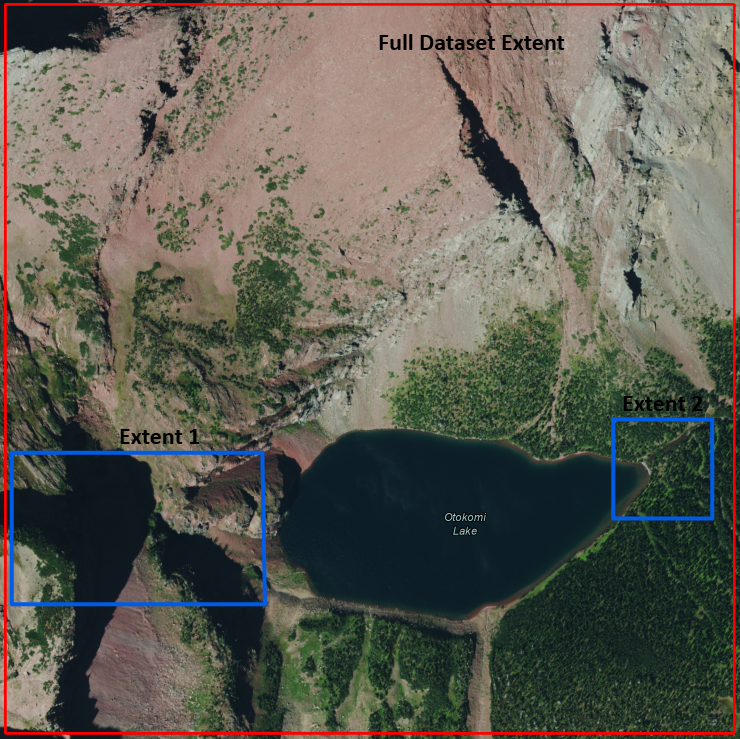

In [ ]:
las<-readLAS("lidar_site.laz", #here is where you would put the full file address for readLAS to access
filter = "-keep_x 298008.69, 298356.147, -keep_y 504177.18, 504385.04" #Extent 1
)

Start by accessing the LAZ file through the lidR package.
The filter argument allows us to reduce initial computation by only targetting specific location or technical components of lidar data like the scan angle. See the link here to see other methods of filtering: [Filtering Options](https://github.com/reblekah/UASLidarWorkshop_SKC_2026/blob/main/Filtering%20Options)

For our purposes today, we are filtering our analysis to two major places. First, we're going to use Extent 1.


We've imported the LAZ file, but "print(las)" will show us what's inside.
First, the dataset is 341 MB, but if we would have imported the whole extent, we would have over 4GB of data. This can be processed but for the most part, breaking it down into smaller pieces is a good idea.
It looks like we have about 5 million points, but there may be some repeats.

In [ ]:
print(las)

Let's see how complete the data is by examining the data itself for many common issues in lidar data. According to the documentation:

"For a LAS object it checks:
* if the point cloud is valid according to las specification
* if the header is valid according to las specification
* if the point cloud is in accordance with the header
* if the point cloud has duplicated points and degenerated ground points
* if gpstime and pulses are consistent
* it the coordinate reference sytem is correctly recorded
* if some pre-processing, such as normalization or ground filtering, is already done.
* and much more"


In [ ]:
las_check(las)

If you'll notice "Checking duplicate points" has found that 2585  points have matching coordinates with other points. This isn't uncommon in lidar data, so let's drop those.

In [ ]:
las_clean<-filter_duplicates(las)

Let's remove our original data and focus on our las_clean file. We can always access the original if we need to. We're doing this to keep our working environment tidy but also making sure we don't run into processing caps Google Colab puts in place.

Remember, this code is just a sample and there are ways to manage large datasets. I would be happy to help make recommendations or provide support if you need.

In [ ]:
rm(las) #remove the original lidar file - we can always get it back!
gc() #clear out some of Colab's unused memory

##Examining our dataset

We've filtered our point data to prevent duplicates, but what does the data even look like?

Las/Laz files contain attributes for all points within a point cloud. Those attributes typically contain the X, Y, and Z coordinates, Intensity, any reflectance data if collected as well as returns, scan directions, gps time etc.
We will work our way through some of this data, but for now, let's just look at the data temporarily in a dataframe or table.

In [ ]:
head(las_clean@data)

Point clouds are not easily visualized in Google Colab unfortunately, but we can visualize some cross sections instead.

In [ ]:
file_id <- "1Pqhu2O0g_JJihOFI7jEsbgLWjeX3besP" #Actual link to shared file: https://drive.google.com/file/d/1Pqhu2O0g_JJihOFI7jEsbgLWjeX3besP/view?usp=sharing
public_file <- drive_get(as_id(file_id))
drive_download(public_file, path = "FilteringPolygons.zip", overwrite = TRUE)
unzip("FilteringPolygons.zip")
Filter_poly<-sf::st_read("FilteringPolygons.shp")
Extent1<-Filter_poly[1, ]
print(ext(Extent1))

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)#increase the size of the figures we're plotting

p1 <- c(298100, 504200) # c(x, y)
p2 <- c(298250, 504250) #feel free to change p1 or p2 to any points within our SpatExtent shown above to look at other cross sections.
las_tr <- clip_transect(las_clean, p1, p2, width =5, xz = TRUE)

ggplot(payload(las_tr), aes(x = X, y = Z, color = Z)) +
  geom_point(size = 0.5, alpha = 0.6) +
  coord_equal()+
  scale_color_viridis_c(option = "terrain") +
  labs(title = "Vertical Point Cloud Cross-Section", x = "Distance (X)", y = "Elevation (Z)") +
  theme_minimal()

Below is the location of the cross-section we plotted.

In [ ]:
crosssection<- as.data.frame(rbind(p1,p2))
colnames(crosssection)<-c("lat", "long")
crosspoints<- st_as_sf(crosssection, coords = c("lat", "long"),crs=st_crs(Filter_poly))

ggplot()+
  geom_sf(data = Extent1, color = "Blue")+
  geom_sf(data = crosspoints, color = "Grey30")+
  theme_minimal()

In [ ]:
thinned<-decimate_points(las_clean,random(5))

ggplot(payload(thinned),aes(X,Y,color = Intensity)) +
  geom_point(size = 0.5)+
  theme_minimal()+
  coord_equal()+
  scale_color_gradientn(colours=height.colors(50))

##More advanced surface generation

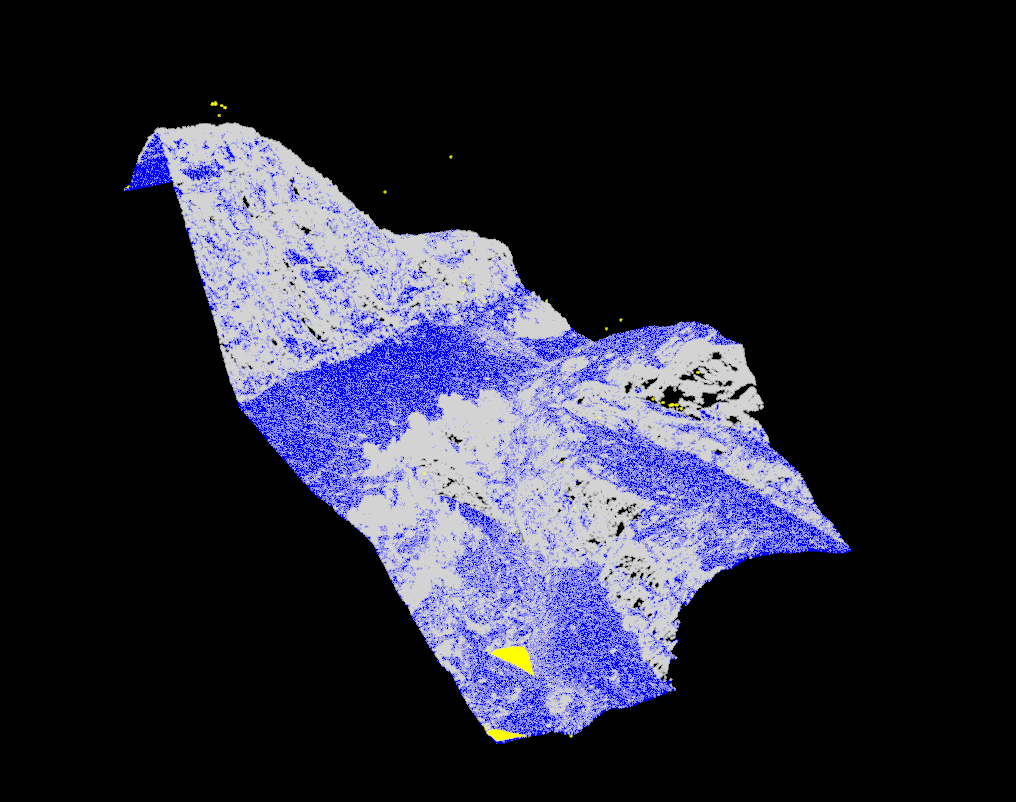

Above is a 3D representation of the area we're mapping. Unfortunately Google Colab does not have 3D mapping capabilities, but hopefully this visualization helps you see what we're working with.
The grey, blue, and yellow colors all represent different classifications of point data, grey is unclassified, blue is ground, yellow are errors, noise or potentially vegetation.

A common use of lidar data is to generate digital surface or digital terrain models. This is fairly easy to do using the lidR package.

In [ ]:
plot(rasterize_terrain(las_clean, res=0.05,use_class = 2), col=terrain.colors(15))

In [ ]:
table(las_clean$Classification)

Some of this data is already classified as "ground" (Classification = 2).
Let's see if we can classify any additional points as "ground".

In [ ]:
mycsf <- csf(TRUE, 0.5, 0.5, time_step = 0.65) #this is an algorithm to select ground points based on a handful of variable inputs.
las_clean <- classify_ground(las_clean, mycsf)

ter<-rasterize_terrain(las_clean, res=1,use_class = 2)
plot(ter, col=terrain.colors=15)

What the figure above shows us is a rough DTM. We used a k-nearest neighbor algorithm which checks "k" nearby points and weighs them to determine each pixel's value. This is a functional algorithm for our purposes, but there are many ways to separate ground, vegetation, water, and more.

We used the Cloth Simulation Filter which flips our dataset over and "drapes" a cloth on top to find the surface and generate a digital terrain model (DTM).

In [ ]:
table(las_clean$Classification)

We updated our classification to include an additional 275,554 ground points. But notice if we look at the cross section, we lost some of our steeper areas. Let's try again, this time, with a new algorithm.

In [ ]:
#SpatExtent : 298008.691, 298356.14, 504177.18, 504385.039 (xmin, xmax, ymin, ymax)
p1 <- c(298050, 504200) # c(x, y)
p2 <- c(298300, 504200) #feel free to change p1 or p2 to any points within our SpatExtent shown above to look at other cross sections.
las_tr <- clip_transect(las_clean, p1, p2, width =1, xz = TRUE)

ggplot(payload(las_tr), aes(x = X, y = Z, color = Classification)) +
  geom_point(size = 0.5, alpha = 0.6) +
  coord_equal()+
  scale_color_viridis_c() +
  labs(title = "Vertical Point Cloud Cross-Section", x = "Distance (X)", y = "Distance (Z)") +
  theme_minimal()

In [ ]:
crosssection<- as.data.frame(rbind(p1,p2))
colnames(crosssection)<-c("lat", "long")
crosspoints<- st_as_sf(crosssection, coords = c("lat", "long"),crs=st_crs(Filter_poly))

ggplot()+
  geom_sf(data = Extent1, color = "Blue")+
  geom_sf(data = crosspoints, color = "Grey30")+
  theme_minimal()

The next ground classification algorithm uses a progressive filter that looks at the nearby points in progressively larger windows. This has an advantage to the last algorithm becuase instead of looking at the whole point cloud like the Cloth Simulation Filter, this algorithm accounts for spatial variation between ground surfaces.

In [ ]:
unclass<-filter_poi(las_clean, Classification ==1)
las_gc<-classify_ground(unclass, algorithm = pmf(ws=5,th=1.5))

ggplot(payload(las_gc),aes(X,Y,color = Classification)) +
  geom_point(size = 0.5)+
  theme_minimal()+
  scale_color_gradientn(colours=height.colors(50))

In [ ]:
#SpatExtent : 298008.691, 298356.14, 504177.18, 504385.039 (xmin, xmax, ymin, ymax)
p1 <- c(298050, 504200) # c(x, y)
p2 <- c(298300, 504200) #feel free to change p1 or p2 to any points within our SpatExtent shown above to look at other cross sections.
las_tr <- clip_transect(las_gc, p1, p2, width =1, xz = TRUE)

ggplot(payload(las_tr), aes(x = X, y = Z, color = Classification)) +
  geom_point(size = 0.5, alpha = 0.6) +
  coord_equal()+
  scale_color_viridis_c() +
  labs(title = "Vertical Point Cloud Cross-Section", x = "Distance (X)", y = "Distance (Z)") +
  theme_minimal()

Now, if we look at the density of our points, you'll see the areas that were misclassified earlier have high point densities. This means there are more points within those areas. Our PMF algorithm was able to use the density of points in the steep areas to more clearly define the ground.

In [ ]:
unclassed<-filter_poi(las_clean, Classification ==1)
plot(rasterize_density(unclassed))

In [ ]:
las_class<-rbind(las_clean,las_gc) #combine our classed dataset to plot classifications together
ter<-rasterize_terrain(las_class, res=1,use_class = 2)
plot(ter, col=terrain.colors(15))
contour(ter, nlevels=10,add=TRUE) #we can also add some contour lines for fun

In [ ]:
#SpatExtent : 298008.691, 298356.14, 504177.18, 504385.039 (xmin, xmax, ymin, ymax)
p1 <- c(298050, 504200) # c(x, y)
p2 <- c(298300, 504200) #feel free to change p1 or p2 to any points within our SpatExtent shown above to look at other cross sections.
las_tr <- clip_transect(las_class, p1, p2, width =1, xz = TRUE)

ggplot(payload(las_tr), aes(x = X, y = Z, color = Classification)) +
  geom_point(size = 0.5, alpha = 0.6) +
  coord_equal()+
  scale_color_viridis_c() +
  labs(title = "Vertical Point Cloud Cross-Section", x = "Distance (X)", y = "Distance (Z)") +
  theme_minimal()

This shows us somewhat of a size profile of our

In [ ]:
writeRaster(rasterize_terrain(las_class,res=1,use_class = 2), "DTM_Ext1.tif")

We can finally export that raster at a 1m resolution. This function automatically stores it in your local files to the left of the screen. You can download that .tif file directly to your personal files.
In order to convert the las file, you must use "rasterize_terrain" which selects our class (ground = class 2) and converts the point cloud to a raster based on the resolution you select.

#Canopies and more complex algorithms

Now we're going to use the lidR package to identify tree tops. Since our first extent had limited trees, we are going to move to a new spot.

In [ ]:
rm(las_clean)
rm(las_class)
rm(unclass)
rm(unclassed)
rm(las_gc)
gc()

In [ ]:
Extent2<-Filter_poly[2, ]
print(ext(Extent2))

In [ ]:
las<-readLAS("lidar_site.laz", #here is where you would put the full file address for readLAS to access
filter = "-keep_x 298833.95, 298969.75, -keep_y 504294.73, 504430.53" #Extent 2
)
print(las)

In [ ]:
las_check(las)

In [ ]:
las_clean<- filter_duplicates(las)

Here's a visualization of our second extent.
What do you notice?

In [ ]:
plot(rasterize_terrain(filter_poi(las_clean, Classification ==2), res=1)) #anything classified as ground.

Classes

1: Unassigned

2: Ground

7: Low Point (noise)

9: Water

18: High Noise

20: Unknown


In [ ]:
test_poi<-filter_poi(las_clean, Classification==1) #run with ground, water, non-ground

ggplot(payload(test_poi),aes(X,Y,color = Z)) +
  geom_point(size = 0.5)+
  theme_minimal()+
  scale_color_gradientn(colours=height.colors(50))

It looks like we have some water pixels that are missclassified. We can fix that with a multi-step filter.

In [ ]:
poi <- ~Classification==1 & Z<1983
las_clean<- classify_poi(las_clean, LASWATER, poi=poi, by_reference=TRUE)


ggplot(payload(filter_poi(las_clean,Classification==1)),aes(X,Y,color = Z)) +
  geom_point(size = 0.5)+
  theme_minimal()+
  scale_color_gradientn(colours=height.colors(50))

##Digital Terrain Model
Following similar methods to the ones we explored above, let's generate a digital terrain model in preparation for individual tree detection and canopy height modeling.

In [ ]:
drain_ground<-rasterize_terrain(las_clean, res=0.5, algorithm = tin(), use_class = 2)
plot(drain_ground)

We can always tweak the algorithm we use. For example, this one used some triangulation across the surface of the water.

In the interest of time, we are going to use what we've generated for our next step.

##Individual Tree Detection and segmentation

Here is what our point cloud looks like in 3D. Notice how we have a bunch of trees along the bank and moving up in elevation? Let's classify those.

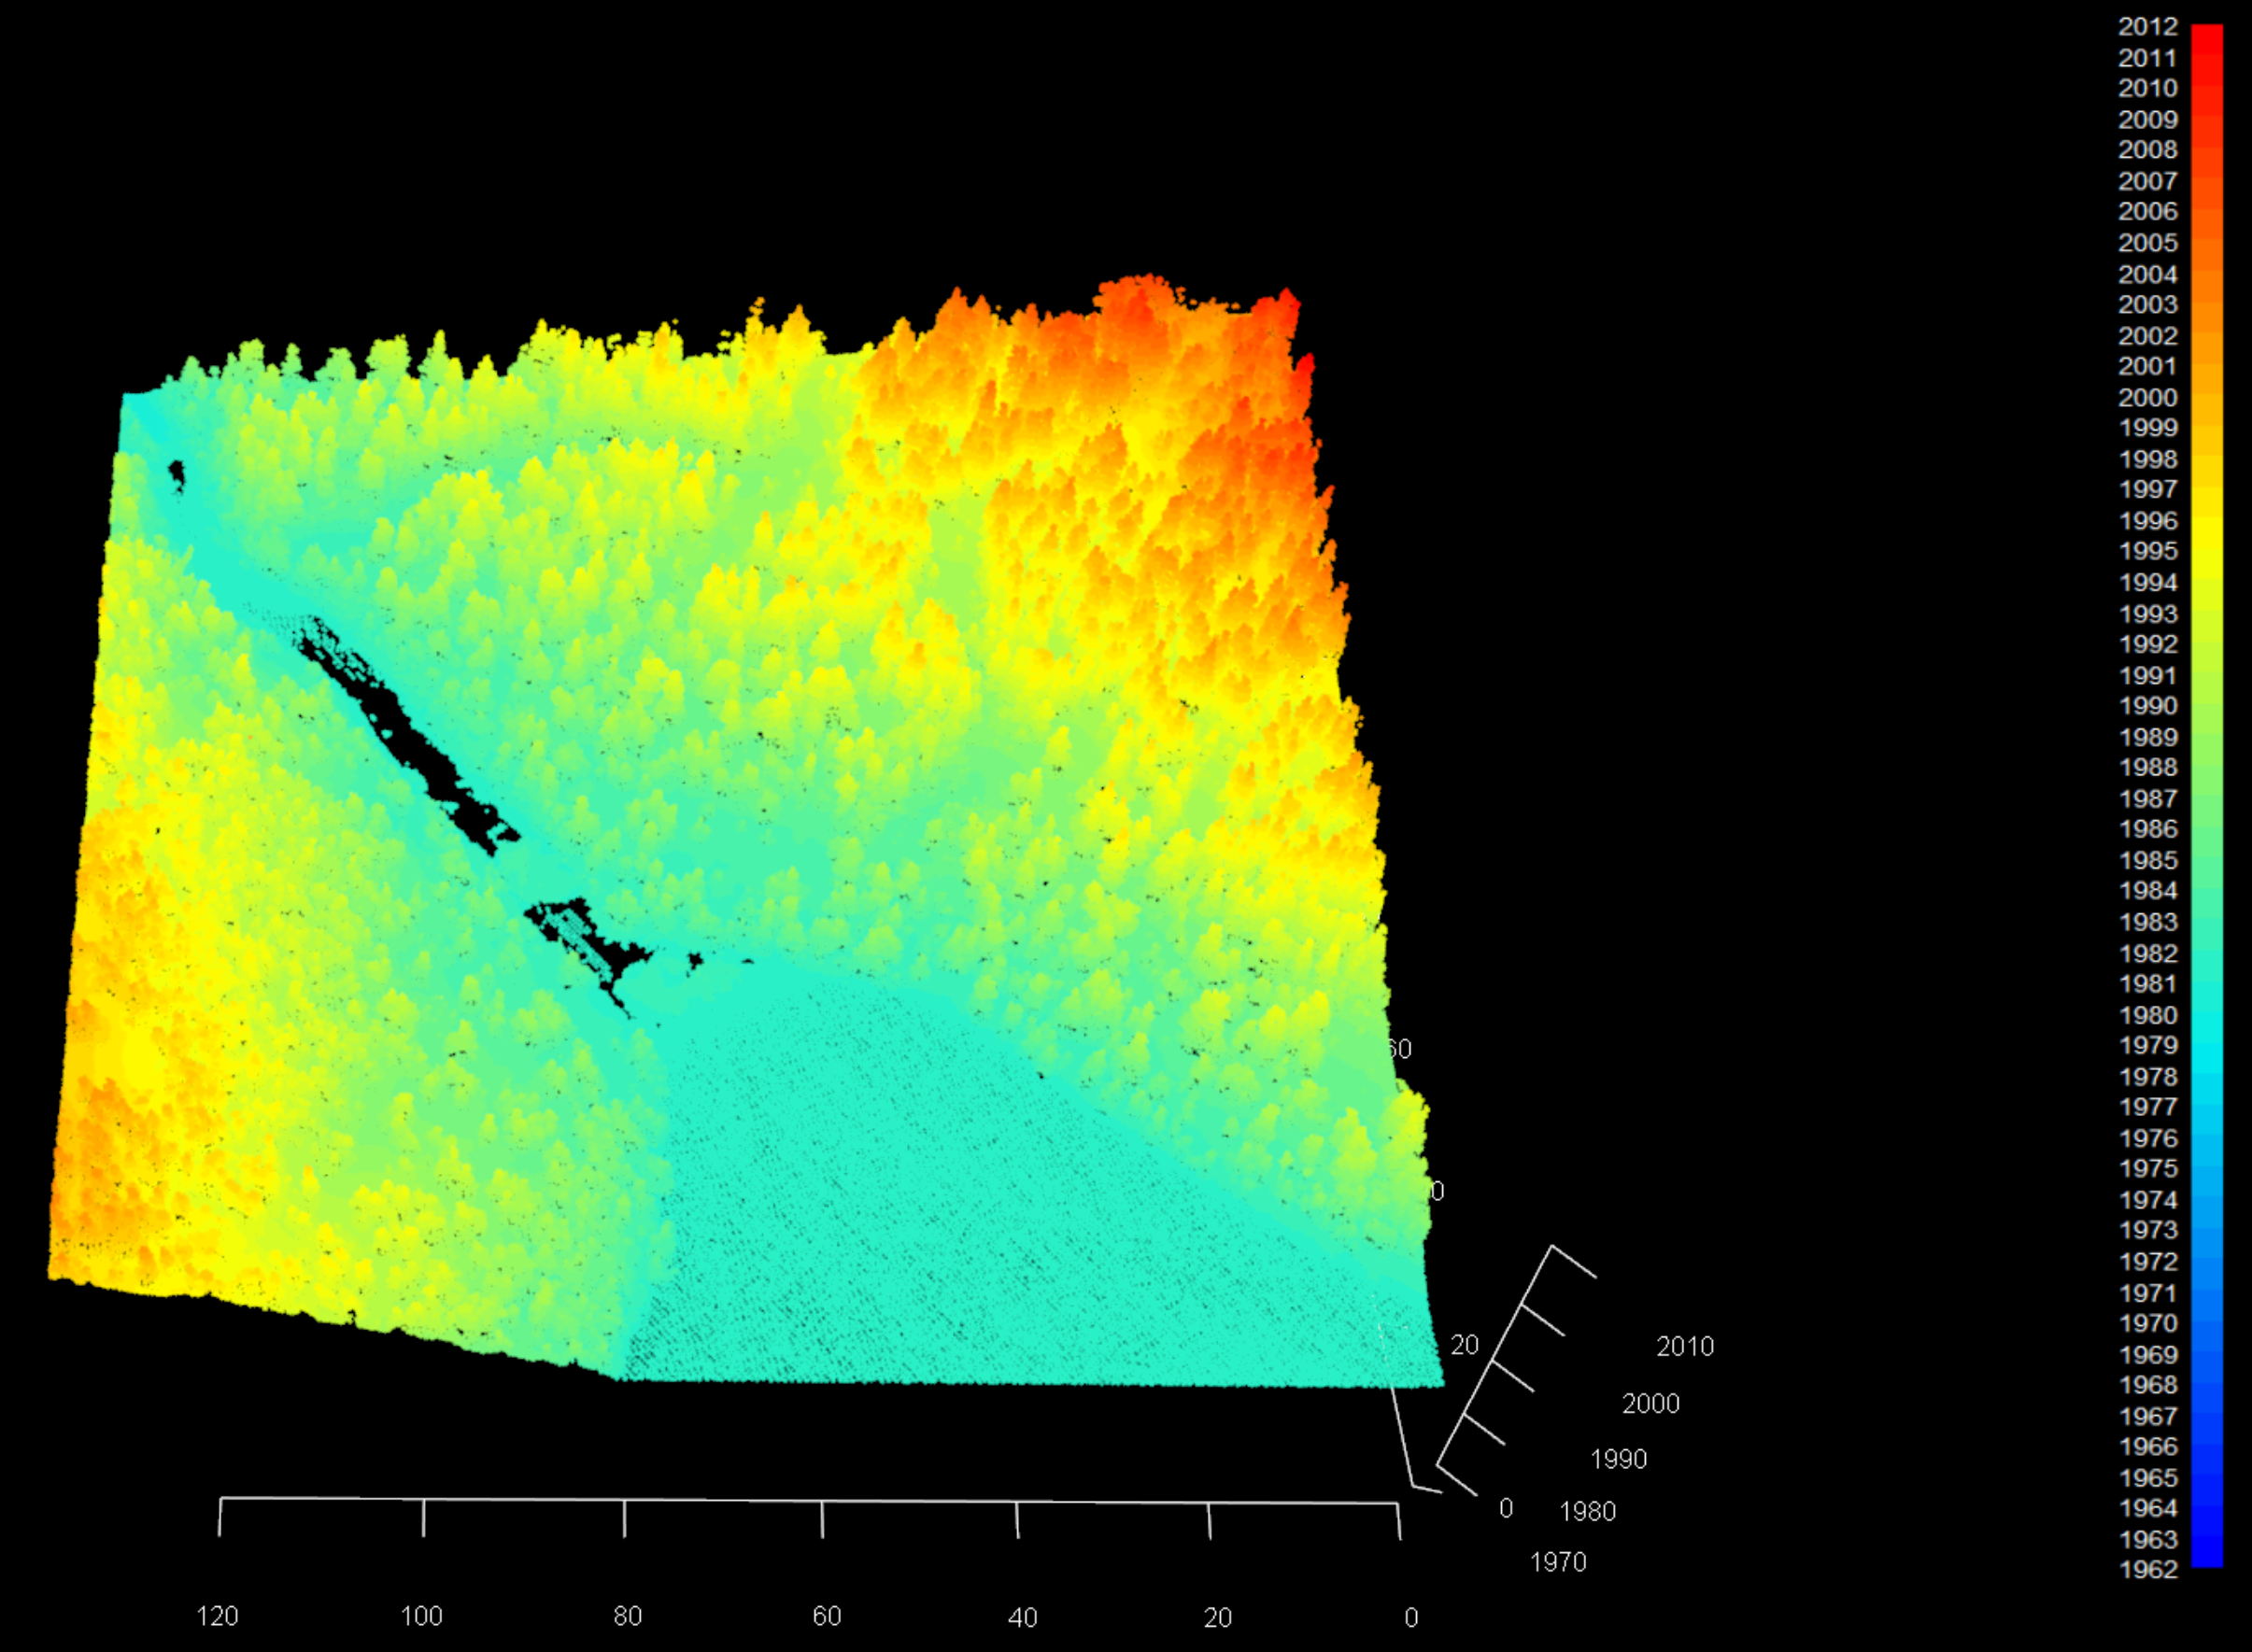

In [ ]:
non_ground<-filter_poi(las_clean,Classification==1)
trees<-locate_trees(non_ground, lmf(ws=5))
canopy<-rasterize_canopy(non_ground, 0.5)
plot(canopy, col=height.colors(20))
plot(sf::st_geometry(trees), add=TRUE, pch=4)

Above, we have the locations of identified trees. We can look at the dataframe though, and get a feel for some of the height metrics.

In [ ]:
print(head(trees))

In [ ]:
min(trees$Z)

That height is based on the elevation! Let's correct that to get a feel for stand structure.

In [ ]:
tree_norm<-non_ground - drain_ground
ttops_norm<-locate_trees(tree_norm, lmf(ws=5))
plot(canopy, col=height.colors(20))
plot(sf::st_geometry(ttops_norm), add=TRUE, pch=4)

In [ ]:
min(ttops_norm$Z)

Now our minimum height is about 2 meters. That makes a little more sense!

##Crown Metrics and Segmentation

We can also take some time to segment our trees (separate them from nearby pixels) and look at the crown metrics of this stand.

In [ ]:
tree_seg<-segment_trees(tree_norm, li2012(R=3, speed_up = 5))
crowns <- crown_metrics(tree_seg, func = .stdtreemetrics, geom = "convex")
print(crowns)

In [ ]:
plot(crowns, col=pastel.colors(200))

In [ ]:
crowns_dalponte <- crown_metrics(las, func = NULL, attribute = "IDdalponte", geom = "concave")
crowns_li <- crown_metrics(las, func = NULL, attribute = "IDli", geom = "concave")

par(mfrow=c(1,2),mar=rep(0,4))
plot(sf::st_geometry(crowns_dalponte), reset = FALSE)
plot(sf::st_geometry(crowns_li), reset = FALSE)